---
title: Deep Learning <code>assignment-1</code>
descrption: Deep Learning Assignment-1
author: Poornima Bhatia
date: 'February 21, 2025'
categories: ['Fashion-MNIST']
image: True
foramt:
html:
code-fold: true
---

### Question 1.
In this assignment you need to implement a feedforward neural network and write the backpropagation
code for training the network from scratch. Use numpy for all matrix/vector operations. You are not
allowed to use any automatic differentiation packages. This network will be trained and tested using the
Fashion-MNIST dataset. Specifically, given an input image (28 x 28 = 784 pixels) from the Fashion-MNIST
dataset, the network will be trained to classify the image into 1 of 10 classes.

1. (A) Download the fashion-MNIST dataset and plot 1 sample image for each class in a grid. Use the
following code for getting the fashion mnist dataset.
```
train_set = torchvision.datasets.FashionMNIST("./data", download=True, transform=
transforms.Compose([transforms.ToTensor()]))
test_set = torchvision.datasets.FashionMNIST("./data", download=True, train=False, transform=
transforms.Compose([transforms.ToTensor()]))
```

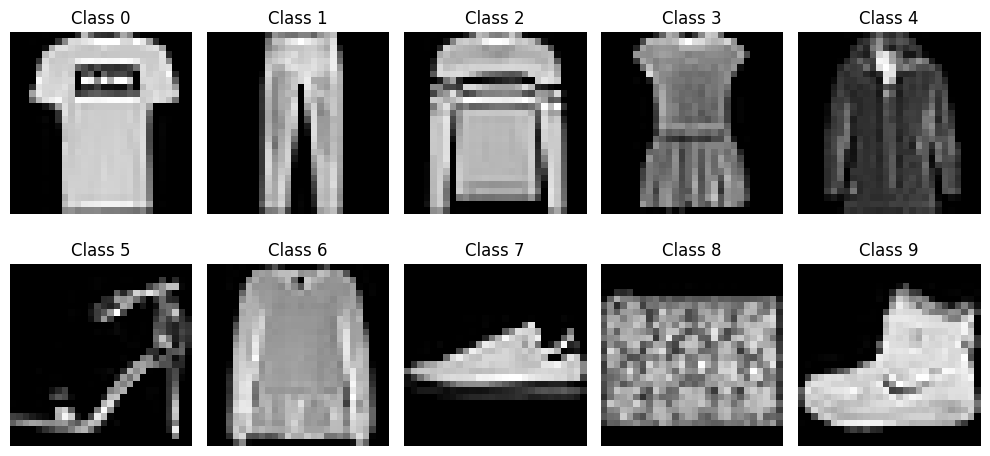

In [ ]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# Load the Fashion-MNIST dataset
train_set = torchvision.datasets.FashionMNIST(
    "./data",
    download=True,
    transform=transforms.Compose([transforms.ToTensor()])
)

test_set = torchvision.datasets.FashionMNIST(
    "./data",
    download=True,
    train=False,
    transform=transforms.Compose([transforms.ToTensor()])
)

# Create a dictionary to store one sample image from each class
class_samples = {i: None for i in range(10)}

# Iterate through the training dataset to capture one sample per class
for img, label in train_set:
    if class_samples[label] is None:
        class_samples[label] = img
    if all(value is not None for value in class_samples.values()):
        break  # Stop once we have one image for each class

# Plot one sample image for each class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

for i in range(10):
    img = class_samples[i].squeeze(0)  # Remove the channel dimension (1, 28, 28 -> 28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Class {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


---

1. (B) Implement a feedforward neural network using numpy which takes images from the fashion-mnist data as input and outputs a probability distribution over the 10 classes. Use only one hidden layer.

1. (C) Implement from scratch the backpropagation algorithm with support for the following optimization functions — sgd, momentum based gradient descent.

In [ ]:
# both (B) and (C)

class FeedforwardNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=1e-4, weight_decay=0.5, activation='relu', weight_init='random' , beta=0.9):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.activation = activation
        self.weight_init = weight_init
        self.beta = beta

        # Weight initialization (Xavier or random)
        if weight_init == 'xavier':
            self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / (input_size + hidden_size))
            self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / (hidden_size + output_size))
        else:
            self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)
            self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)

        self.b1 = np.zeros((1, hidden_size))
        self.b2 = np.zeros((1, output_size))

        # Momentum parameters for gradient updates
        self.VdW1 = np.zeros_like(self.W1)
        self.Vdb1 = np.zeros_like(self.b1)
        self.VdW2 = np.zeros_like(self.W2)
        self.Vdb2 = np.zeros_like(self.b2)

    def relu(self, x):
        return np.maximum(0, x)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # For numerical stability
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        if self.activation == 'relu':
            self.A1 = self.relu(self.Z1)
        else:
            self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, Y, Y_pred):
        m = Y.shape[0]  # Number of samples
        loss = -np.mean(np.sum(Y * np.log(Y_pred + 1e-8), axis=1))  # Cross-entropy loss

        # Adding weight decay (L2 regularization)
        l2_reg = self.weight_decay * (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2))) / (2 * m)

        return loss + l2_reg  # Now `loss` is properly defined before adding L2 regularization


    def backward(self, X, Y):
        m = X.shape[0]

        # Compute gradients for the output layer
        dZ2 = self.A2 - Y
        dW2 = np.dot(self.A1.T, dZ2) / m + (self.weight_decay * self.W2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Compute gradients for the hidden layer
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.A1 > 0)  # Derivative of ReLU
        dW1 = np.dot(X.T, dZ1) / m + (self.weight_decay * self.W1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Momentum-based updates
        self.VdW1 = self.beta * self.VdW1 + (1 - self.beta) * dW1
        self.Vdb1 = self.beta * self.Vdb1 + (1 - self.beta) * db1
        self.VdW2 = self.beta * self.VdW2 + (1 - self.beta) * dW2
        self.Vdb2 = self.beta * self.Vdb2 + (1 - self.beta) * db2

        # Update weights and biases
        self.W1 -= self.learning_rate * self.VdW1
        self.b1 -= self.learning_rate * self.Vdb1
        self.W2 -= self.learning_rate * self.VdW2
        self.b2 -= self.learning_rate * self.Vdb2

    def train(self, X_train, Y_train, X_val, Y_val, epochs=10, batch_size=64):
        for epoch in range(epochs):
            # Shuffle the training data
            perm = np.random.permutation(X_train.shape[0])
            X_train, Y_train = X_train[perm], Y_train[perm]

            for i in range(0, X_train.shape[0], batch_size):
                X_batch = X_train[i:i + batch_size]
                Y_batch = Y_train[i:i + batch_size]

                # Forward pass
                Y_pred = self.forward(X_batch)

                # Compute loss
                loss = self.compute_loss(Y_batch, Y_pred)

                # Backward pass
                self.backward(X_batch, Y_batch)

            # Compute validation loss
            val_pred = self.forward(X_val)
            val_loss = self.compute_loss(Y_val, val_pred)
            print(f"Epoch {epoch+1}, Training Loss: {loss}, Validation Loss: {val_loss}")

    def predict(self, X):
        # Use the trained model to make predictions on input data X
        output = self.forward(X)
        return np.argmax(output, axis=1)  # Assuming softmax output, return the index of the highest probability

    def predict_prob(self, X):
        output = self.forward(X)
        probabilities = output  # Get the probability distribution for each class
        total_probabilities = np.sum(probabilities, axis=1)  # Sum of probabilities for each sample

        print("Probabilities:\n", probabilities)  # Print the probabilities
        print("Total Probability per Sample:\n", total_probabilities)  # Print the sum of probabilities per sample

        return probabilities


    def evaluate(self, X, y):
        # Forward pass through the network to get predictions
        predictions = self.predict(X)

        # Get true labels (y) by converting one-hot encoded labels back to the original class labels
        true_labels = np.argmax(y, axis=1)

        print("\nPredicted probabilities:")
        _ = self.predict_prob(X)

        # Calculate accuracy (number of correct predictions / total predictions)
        accuracy = np.mean(predictions == true_labels)
        return accuracy

---

1. (D) Use the standard train/test split of fashioMnist (use (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()). Keep 10% of the training data aside as validation data for this hyperparameter search. Here are some suggestions for different values to try for hyperparameters.
* number of epochs: 10
* weight decay (L2 regularisation): 0.5
* batch size: 64
* learning rate: 1e-4
* activation functions: ReLU
* size of hidden layer: 64, 128
* optimizer: sgd, momentum.
* weight initialisation: random, Xavier

In [ ]:
# Accessing the data from the PyTorch dataset
X_train = train_set.data.numpy().astype(np.float32) / 255.0
X_test = test_set.data.numpy().astype(np.float32) / 255.0
y_train = train_set.targets.numpy()
y_test = test_set.targets.numpy()

# Flatten the images to 1D vectors (28x28 -> 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Split 10% of the training data for validation
validation_size = int(0.1 * X_train.shape[0])
X_val, X_train = X_train[:validation_size], X_train[validation_size:]
y_val, y_train = y_train[:validation_size], y_train[validation_size:]

# One-hot encode the labels (if necessary)
def one_hot_encode(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train = one_hot_encode(y_train)
y_val = one_hot_encode(y_val)
y_test = one_hot_encode(y_test)

# Hyperparameters for the search
epochs = 10
batch_size = 64
learning_rate = 1e-4
weight_decay = 0.5
hidden_sizes = [64, 128]
weight_initializations = ['random', 'xavier']
activations = ['relu']
optimizers = ['sgd', 'momentum']

# Keep track of the best models' configurations
results = []

# Train the model with different hyperparameters
for hidden_size in hidden_sizes:
    for weight_init in weight_initializations:
        for optimizer in optimizers:
            print(f"Training with hidden_size={hidden_size}, weight_init={weight_init}, optimizer={optimizer}")
            nn = FeedforwardNN(input_size=784, hidden_size=hidden_size, output_size=10,
                               learning_rate=learning_rate, weight_decay=weight_decay,
                               activation='relu', weight_init=weight_init)
            nn.train(X_train, y_train, X_val, y_val, epochs=epochs, batch_size=batch_size)

            # After training, calculate the validation accuracy
            val_accuracy = nn.evaluate(X_val, y_val)  # Assuming you have a method for evaluation

            # Store results: Include configuration and validation accuracy
            results.append({
                'hidden_size': hidden_size,
                'weight_init': weight_init,
                'optimizer': optimizer,
                'val_accuracy': val_accuracy
            })

# Sort results by validation accuracy (descending)
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

Training with hidden_size=64, weight_init=random, optimizer=sgd
Epoch 1, Training Loss: 2.676790204320948, Validation Loss: 2.2613488761731104
Epoch 2, Training Loss: 2.584740413664985, Validation Loss: 2.1779742649134963
Epoch 3, Training Loss: 2.5111290172312626, Validation Loss: 2.105219432574522
Epoch 4, Training Loss: 2.3939002084343204, Validation Loss: 2.0378480626670306
Epoch 5, Training Loss: 2.333259072360249, Validation Loss: 1.973958460229051
Epoch 6, Training Loss: 2.2202273644901593, Validation Loss: 1.9128370832337587
Epoch 7, Training Loss: 2.207059735753662, Validation Loss: 1.8539733524361226
Epoch 8, Training Loss: 2.126729299971257, Validation Loss: 1.7973543267313168
Epoch 9, Training Loss: 2.191201604869426, Validation Loss: 1.7429490070537097
Epoch 10, Training Loss: 2.0045864328681047, Validation Loss: 1.691010410210745

Predicted probabilities:
Probabilities:
 [[0.01873367 0.02451388 0.0597694  ... 0.15229394 0.1972093  0.31634945]
 [0.24818242 0.10011529 0.172

---

1. (E) Based on this, report configurations that are giving the top 3 accuracies. For the best model obtained, report the accuracy on the test set of fashionMnist and report the confusion matrix.

Top 1 Configuration: {'hidden_size': 128, 'weight_init': 'xavier', 'optimizer': 'momentum', 'val_accuracy': 0.6633333333333333}
Top 2 Configuration: {'hidden_size': 64, 'weight_init': 'xavier', 'optimizer': 'sgd', 'val_accuracy': 0.6555}
Top 3 Configuration: {'hidden_size': 64, 'weight_init': 'xavier', 'optimizer': 'momentum', 'val_accuracy': 0.6531666666666667}
Retraining best model with hidden_size=128, weight_init=xavier, optimizer=momentum
Epoch 1, Training Loss: 3.308676533079087, Validation Loss: 2.0960707326482297
Epoch 2, Training Loss: 3.1224547313180384, Validation Loss: 1.9250523598175202
Epoch 3, Training Loss: 2.986602902493691, Validation Loss: 1.7903958911464215
Epoch 4, Training Loss: 3.0149663592712557, Validation Loss: 1.6789626062238532
Epoch 5, Training Loss: 2.9327201398409146, Validation Loss: 1.585009873678236
Epoch 6, Training Loss: 2.6867623135611765, Validation Loss: 1.5046628617894404
Epoch 7, Training Loss: 2.589383728463414, Validation Loss: 1.4358138944854

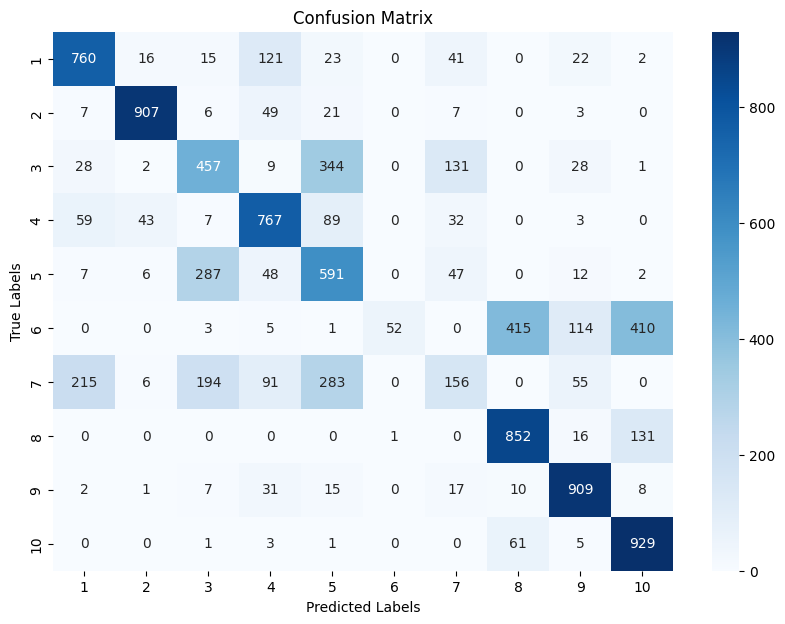

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Top 3 configurations
top_3_configs = results[:3]
for i, config in enumerate(top_3_configs, start=1):
    print(f"Top {i} Configuration: {config}")

# Select the best configuration (the one with highest validation accuracy)
best_config = top_3_configs[0]
best_hidden_size = best_config['hidden_size']
best_weight_init = best_config['weight_init']
best_optimizer = best_config['optimizer']

# Retrain the best model on the entire training data (including validation)
print(f"Retraining best model with hidden_size={best_hidden_size}, weight_init={best_weight_init}, optimizer={best_optimizer}")
best_nn = FeedforwardNN(input_size=784, hidden_size=best_hidden_size, output_size=10,
                        learning_rate=learning_rate, weight_decay=weight_decay,
                        activation='relu', weight_init=best_weight_init)
best_nn.train(X_train, y_train, X_val, y_val, epochs=epochs, batch_size=batch_size)

# Evaluate the model on the test set
test_accuracy = best_nn.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

# Get the model's predictions on the test set
y_pred = best_nn.predict(X_test)  # Assuming predict method returns predicted labels

# Compute the confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(1,11), yticklabels=np.arange(1 ,11))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

---
---

### Question 2:

The given function is:

$$
f(x) = \frac{1 + \tanh\left(\frac{wx + b}{2}\right)}{2}
$$

The loss function is:

$$
L(x, y) = \frac{(y - f(x))^2}{2}
$$

### Step 1: Compute $ \frac{\partial L}{\partial w} $

1. **Compute $ \frac{\partial L}{\partial f(x)} $:**

$$
\frac{\partial L}{\partial f(x)} = -(y - f(x))
$$

2. **Compute $ \frac{\partial f(x)}{\partial w} $:**

$$
\frac{\partial f(x)}{\partial w} = \frac{x}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

3. **Apply the chain rule:**

$$
\frac{\partial L}{\partial w} = -(y - f(x)) \cdot \frac{x}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

Thus, the partial derivative with respect to $ w $ is:

$$
\frac{\partial L}{\partial w} = - \frac{(y - f(x)) \cdot x}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

### Step 2: Compute $ \frac{\partial L}{\partial b} $

1. **Compute $ \frac{\partial f(x)}{\partial b} $:**

$$
\frac{\partial f(x)}{\partial b} = \frac{1}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

2. **Apply the chain rule:**

$$
\frac{\partial L}{\partial b} = -(y - f(x)) \cdot \frac{1}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

Thus, the partial derivative with respect to $ b $ is:

$$
\frac{\partial L}{\partial b} = - \frac{(y - f(x))}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

### Final Results:

The partial derivatives of the loss function with respect to $ w $ and $ b $ are:

$$
\frac{\partial L}{\partial w} = - \frac{(y - f(x)) \cdot x}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$

$$
\frac{\partial L}{\partial b} = - \frac{(y - f(x))}{4} \cdot \text{sech}^2\left(\frac{wx + b}{2}\right)
$$


---
---

### Question 3:
A network consists of three 1D convolutional layers. At each layer, a zero-padded convolution with kernel size seven and stride one is applied. What size is the receptive field of hidden units in the third layer?

### Solution:

Given:
- **Kernel size** = 7
- **Stride** = 1
- **Padding** = 3 (zero padding to preserve the input size)

The receptive field is the size of the region in the input image that contributes to a hidden unit in the output layer. We calculate the receptive field layer by layer.

### Layer 0:
- **Receptive field of layer 0** = 1 (input layer)

#### Layer 1:
- **Receptive field of layer 1** = 7 (since it's the kernel size)

#### Layer 2:
To calculate the receptive field of layer 2, we account for the receptive field from the first layer:
- **Receptive field of layer 2** = Receptive field of layer 1 + (kernel size - 1) * stride
- **Receptive field of layer 2** = 7 + (7 - 1) * 1 = 7 + 6 = 13

#### Layer 3:
To calculate the receptive field of layer 3, we account for the receptive field from the second layer:
- **Receptive field of layer 3** = Receptive field of layer 2 + (kernel size - 1) * stride
- **Receptive field of layer 3** = 13 + (7 - 1) * 1 = 13 + 6 = 19

#### Layer 4:
To calculate the receptive field of layer 4, we account for the receptive field from the thrid layer:
- **Receptive field of layer 4** = Receptive field of layer 3 + (kernel size - 1) * stride
- **Receptive field of layer 4** = 19 + (7 - 1) * 1 = 19 + 6 = 25



### Final Answer:
The receptive field of a hidden unit in the fourth layer is **25**.


---
---

### Question 4:
Write out the equation for a 1D convolution with kernel size of seven, a dilation rate of three, and a stride
of three.

Given:
- **Kernel size** \( K = 7 \)
- **Dilation rate** \( d = 3 \)
- **Stride** \( s = 3 \)

General Formula for 1D Convolution

$$ y[n] = \sum_{i=0}^{K-1} x[n \cdot S + i \cdot D] \cdot w[i] $$

where:
- $ y[n] $ is the output sequence.
- $ x[m] $ is the input sequence.
- $ w[i] $ is the kernel (filter) of size $ K $.
- $ S $ is the **stride** (how much we move each step).
- $ D $ is the **dilation rate** (spacing between kernel elements).
- $ K $ is the **kernel size** (number of elements in the filter).

Now, applying the general equation:

$$
y[n] = \sum_{i=0}^{6} x[n \cdot 3 + i \cdot 3] \cdot w[i]
$$

Expanding for all **7 kernel elements**:

$$
y[n] = x[n \cdot 3 + 0] \cdot w[0] + x[n \cdot 3 + 3] \cdot w[1] + x[n \cdot 3 + 6] \cdot w[2] + x[n \cdot 3 + 9] \cdot w[3] + x[n \cdot 3 + 12] \cdot w[4] + x[n \cdot 3 + 15] \cdot w[5] + x[n \cdot 3 + 18] \cdot w[6]
$$

### Final Equation:
The final equation for the 1D convolution with kernel size 7, dilation rate 3, and stride 3 is:

$$
y[n] = \sum_{i=0}^{6} x[n \cdot 3 + i \cdot 3] \cdot w[i]
$$


---
---